In [ ]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import matthews_corrcoef, confusion_matrix, accuracy_score

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.feature_selection import SelectFromModel
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import resample
import matplotlib.pyplot as plt
import pandas as pd
import model as m
import seaborn as sns
import divide_bins as divide
import numpy as np
import regression as reg


2024-09-27 11:53:05.427794: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-09-27 11:53:05.429747: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2024-09-27 11:53:05.460525: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-09-27 11:53:05.460549: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-09-27 11:53:05.461158: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

In [5]:
#file_name = "/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/outputs/micro_2_Combat_smote_8_classes.csv"
#df = pd.read_csv(file_name)
#df.columns

Index(['U48705', 'M87338', 'X51757', 'X69699', 'L36861', 'L13852', 'X55005',
       'X79510', 'M21121', 'J02843',
       ...
       'AI654857', 'W22117', 'AI028241', 'AI571298', 'AA149545', 'C18318',
       'AI219073', 'AI205180', 'AI363375', 'Age'],
      dtype='object', length=51277)

In [7]:
root = "/home/karen/Documents/phd/Data/Batch_corrected"
root = "/home/karen/Documents/GitHub/batch_correction/Results"
files = [
    #"micro_z_Combat.csv",
    #"RNAs_2_reCombat.csv",
    #"micro_2_Combat.csv",
    #"micro_z_reCombat.csv",
    #"RNAs_z_Combat.csv",
    #"micro_2_reCombat.csv",
    #"RNAs_2_Combat.csv",
    #"RNAs_z_Combat_2.csv",
    #"RNAs_z_reCombat.csv"
    "RNAseq_z_score_adjustedCombat.csv",
    "RNAseq_Combat_z_score_Train_set_SMOTE_noise.csv"

    
]
test_file = "RNAseq_Combat_z_score_Test_set.csv"

In [9]:
def eval_regression_file(f, method="L2"):
    assert method in ["L1", "L2"]
    eval={"File": f}
    if "micro" in f:
        eval["Technology"]="Microarray"
    else:
        eval["Technology"]= "RNAseq"
    
    if "z" in f:
        eval["Normalization"]= "Z-score"
    else:
        eval["Normalization"]="Two-step"
    
    if "reCombat" in f:
        eval["BatchCorrection"]= "reCombat"
    else:
        eval["BatchCorrection"]="Combat"
        
    dataset = pd.read_csv(f"{root}/{f}")
    section_df = dataset.drop(columns=["Age"])
    section_df_age = dataset["Age"]
    section_df = m.remove_non_numeric_columns(section_df)
    if method == "L2":
        result_df, result_metrics, ridge_model = reg.ridge_L2(X=section_df, y=section_df_age, z=dataset["Age"], test_size=0.4)
    elif method == "L1":
        result_df, result_metrics, _ = reg.lasso_L1(X=section_df, y=section_df_age, z=dataset["Experiment"])
    age_ranges = divide.get_age_distribution(result_df["Actual"], age_ranges=[18, 26,35,65,71,72,95])
    y_train_cat = result_df["Actual"].apply(lambda x: divide.assign_age_group(x, age_ranges))
    y_test_cat = result_df["Predicted"].apply(lambda x: divide.assign_age_group(x, age_ranges))

    cat_results = pd.DataFrame({"Actual": y_train_cat, "Predicted": y_test_cat})
    mcc = matthews_corrcoef(cat_results["Actual"], cat_results["Predicted"])
    result_metrics["MCC"]= mcc
    # area under the curve
    auc = accuracy_score(cat_results["Actual"], cat_results["Predicted"])
    result_metrics["AUC"] = auc
    eval.update(result_metrics)

    return eval, result_df, ridge_model


In [10]:
file = files[1]

eval, result_df_rnaseq, ridge_model = eval_regression_file(file, method="L2")

/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [11]:
# save ridge_model on pkl file
import pickle
with open("ridge_model_smote.pkl", "wb") as f:
    pickle.dump(ridge_model, f)
    

In [12]:
eval

{'File': 'RNAseq_Combat_z_score_Train_set_SMOTE_noise.csv',
 'Technology': 'RNAseq',
 'Normalization': 'Z-score',
 'BatchCorrection': 'Combat',
 'Method': 'Ridge Regression',
 'MSE': 66.90612245365685,
 'RMSE': 8.179616277898178,
 'MAE': 6.160145557637911,
 'R2': 0.8686129208970639,
 'MCC': 0.5130575758206664,
 'AUC': 0.6086956521739131}

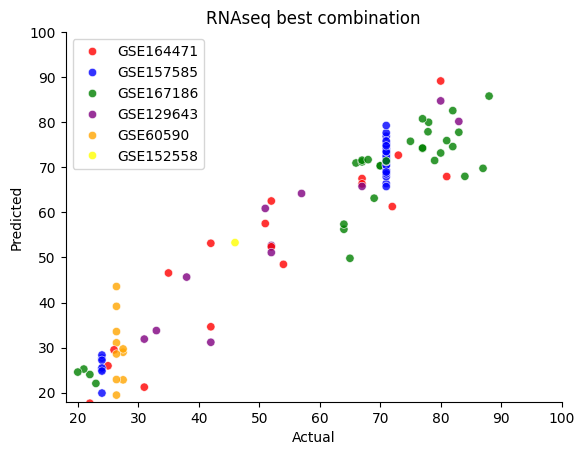

In [15]:
results = result_df_rnaseq
custom_palette = {
        'GSE164471': 'red',
        'GSE157585': 'blue',
        'GSE167186': 'green',
        'GSE129643': 'purple',
        'GSE60590': 'orange',
        'GSE152558': 'yellow'
    }

label_order = ['GSE164471', 'GSE157585', 'GSE167186', 'GSE129643', 'GSE60590', 'GSE152558']

sns.scatterplot(x='Actual', y='Predicted', hue='Group', data=results, palette=custom_palette, hue_order=label_order, alpha=0.8, edgecolor='w')

#plt.scatter(y_test, ridge.predict(X_test), hue=z, label='Predicted')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('RNAseq best combination')
plt.xlim(18, 100)
plt.ylim(18, 100)
plt.legend()


# Get the current axes object
ax = plt.gca()

# Remove the right and top spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Show the plot
plt.savefig("RNAseq_best_combination.png")

plt.show()

In [13]:
result_df_rnaseq

,Actual,Predicted,Group
217,86.0,71.407947,86.0
66,84.0,79.773020,84.0
9,82.0,74.528303,82.0
193,31.0,29.819077,31.0
15,69.0,74.295587,69.0
...,...,...,...
132,22.0,26.912185,22.0
182,29.0,28.002279,29.0
76,86.0,72.221559,86.0
41,72.0,79.127596,72.0


In [ ]:
age_ranges = divide.get_age_distribution(result_df_rnaseq["Actual"], age_ranges=[16, 26,35,65,71,72,96])
age_ranges

In [15]:
y_train_cat = result_df_rnaseq["Actual"].apply(lambda x: divide.assign_age_group(x, age_ranges))
y_test_cat = result_df_rnaseq["Predicted"].apply(lambda x: divide.assign_age_group(x, age_ranges))


cat_results = pd.DataFrame({"Actual": y_train_cat, "Predicted": y_test_cat})
#mcc = matthews_corrcoef(result_df_rnaseq["Actual"], result_df_rnaseq["Predicted"])



In [16]:
mcc = matthews_corrcoef(cat_results["Actual"], cat_results["Predicted"])


In [17]:
cat_results=cat_results[cat_results["Predicted"]!="Unknown"]

In [18]:
confusion_matrix_table = confusion_matrix(cat_results["Actual"], cat_results["Predicted"])
confusion_matrix_table

array([[ 9,  7,  0,  0,  0,  0],
       [ 2,  9,  5,  0,  0,  0],
       [ 1,  0, 16,  0,  0,  1],
       [ 0,  0,  2,  3,  1,  5],
       [ 0,  0,  0,  0,  0,  1],
       [ 0,  0,  3,  2,  2, 21]])

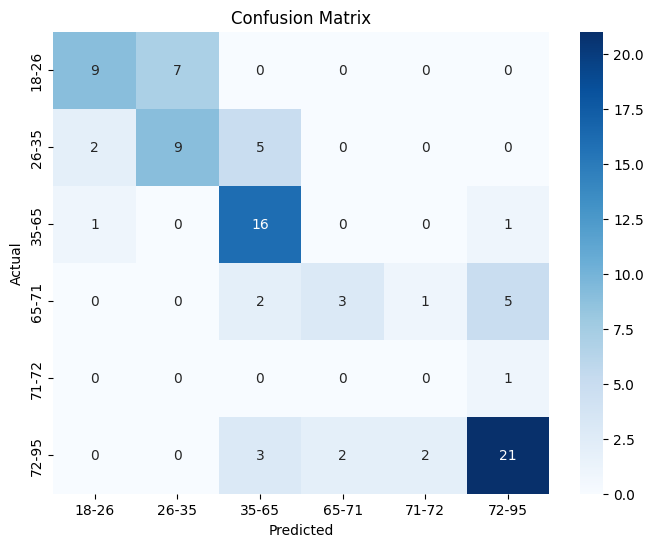

In [19]:
# Plot confusion matrix as heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix_table, cmap='Blues', 
 xticklabels=["18-26", "26-35","35-65","65-71","71-72","72-95"], yticklabels=["18-26", "26-35","35-65","65-71","71-72","72-95"], fmt='d', annot=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig("confusion_matrix_ridge_smote.png")
plt.show()

In [ ]:
# Eval with reserved file

In [1]:
# get ridge_model_from_pkl
import pickle
with open("/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/Ridge/ridge_model_smote.pkl", "rb") as f:
    ridge_model = pickle.load(f)
ridge_model

Ridge()

In [8]:
test_file = root+"/"+test_file
test_file

'/home/karen/Documents/GitHub/batch_correction/Results/RNAseq_Combat_z_score_Test_set.csv'

In [11]:
test_data = pd.read_csv(test_file)
test_data.columns

Index(['ENSG00000000003.14', 'ENSG00000000005.5', 'ENSG00000000419.12',
       'ENSG00000000457.13', 'ENSG00000000460.16', 'ENSG00000000938.12',
       'ENSG00000000971.15', 'ENSG00000001036.13', 'ENSG00000001084.11',
       'ENSG00000001167.14',
       ...
       'ENSG00000285491.1', 'ENSG00000285505.1', 'ENSG00000285508.1',
       'ENSG00000285509.1', 'Age', 'Status', 'Experiment', 'Age.1', 'Sample',
       'Sex'],
      dtype='object', length=34511)

In [12]:
test_data.drop(columns=["Age.1"], inplace=True)

In [13]:
X_test_data = test_data[test_data.columns[:-5]]
z_test_data = test_data[test_data.columns[-4:]]
y_test_data = test_data["Age"]

In [14]:
z_test_data = z_test_data["Experiment"]

In [32]:
results, result_metrics = reg.eval_model(ridge_model=ridge_model, X_test=X_test_data, y_test=y_test_data, z_test=z_test_data)

/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [34]:
result_metrics

{'Method': 'Ridge Regression',
 'MSE': 114.97195810228867,
 'RMSE': 10.722497754827868,
 'MAE': 7.4689775240030025,
 'R2': 0.7703578207036142}

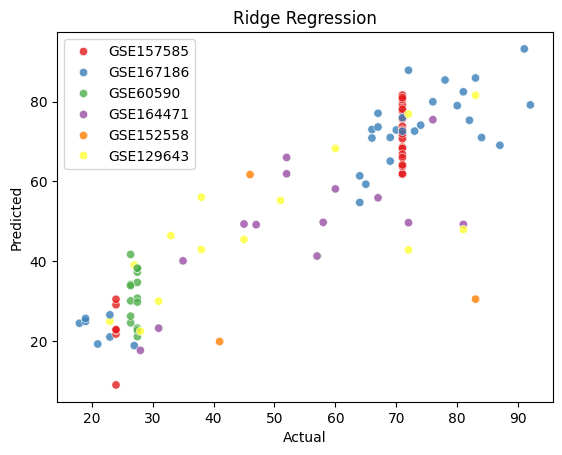

In [36]:
#reg.plotresults has this but does not save the plot``

sns.scatterplot(x='Actual', y='Predicted', hue='Group', data=results, palette='Set1', alpha=0.8, edgecolor='w')

#plt.scatter(y_test, ridge.predict(X_test), hue=z, label='Predicted')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Ridge Regression')
plt.legend()
plt.savefig("Ridge_regression_prediction_smote_untoached.png")
plt.show()

In [39]:
age_ranges = divide.get_age_distribution(results["Actual"], age_ranges=[16, 26,35,65,71,72,96])
age_ranges

[{'label': '16-26', 'range': (16, 26), 'count': 13},
 {'label': '26-35', 'range': (26, 35), 'count': 24},
 {'label': '35-65', 'range': (35, 65), 'count': 17},
 {'label': '65-71', 'range': (65, 71), 'count': 33},
 {'label': '71-72', 'range': (71, 72), 'count': 4},
 {'label': '72-96', 'range': (72, 96), 'count': 17}]

In [40]:
y_train_cat = results["Actual"].apply(lambda x: divide.assign_age_group(x, age_ranges))
y_test_cat = results["Predicted"].apply(lambda x: divide.assign_age_group(x, age_ranges))


cat_results = pd.DataFrame({"Actual": y_train_cat, "Predicted": y_test_cat})

In [41]:
mcc = matthews_corrcoef(cat_results["Actual"], cat_results["Predicted"])

cat_results=cat_results[cat_results["Predicted"]!="Unknown"]

In [42]:
confusion_matrix_table = confusion_matrix(cat_results["Actual"], cat_results["Predicted"])
confusion_matrix_table

array([[ 9,  3,  0,  0,  0,  0],
       [ 8,  8,  7,  0,  0,  0],
       [ 1,  0, 14,  2,  0,  0],
       [ 0,  0,  2,  3,  0,  4],
       [ 0,  0,  4,  5,  2, 14],
       [ 0,  1,  4,  2,  0, 14]])

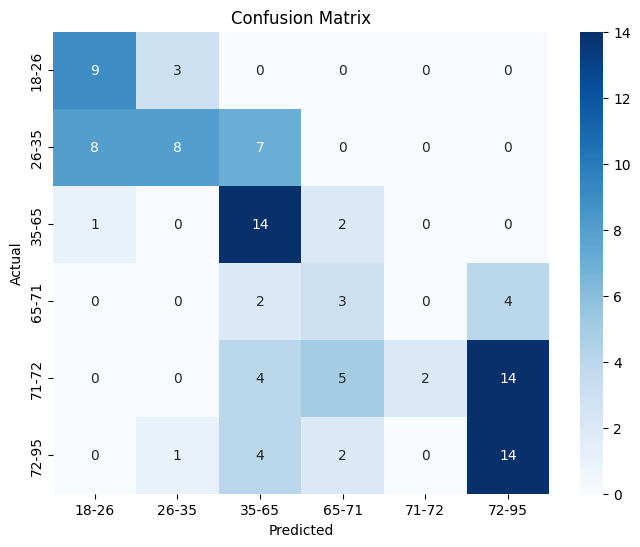

In [43]:
# Plot confusion matrix as heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix_table, cmap='Blues', 
 xticklabels=["18-26", "26-35","35-65","65-71","71-72","72-95"], yticklabels=["18-26", "26-35","35-65","65-71","71-72","72-95"], fmt='d', annot=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig("confusion_matrix_ridge_smote_untoached.png")
plt.show()

In [15]:
coefficients = ridge_model.coef_
feature_names = X_test_data.columns

feature_importance = pd.DataFrame({"Feature": feature_names, "Importance": coefficients})
feature_importance

,Feature,Importance
0,ENSG00000000003.14,0.121967
1,ENSG00000000005.5,0.054519
2,ENSG00000000419.12,0.084876
3,ENSG00000000457.13,0.042627
4,ENSG00000000460.16,0.002908
...,...,...
34500,ENSG00000285480.1,0.035708
34501,ENSG00000285491.1,0.063308
34502,ENSG00000285505.1,0.060353
34503,ENSG00000285508.1,-0.004797


In [16]:
feature_importance.to_csv("feature_importance_ridge_smote_7b.csv", index=False)

In [17]:
feature_importance_path = "/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/Ridge/feature_importance_ridge_smote_7b.csv"

In [18]:
import getting_threshold_genes as gtg

In [19]:
# Elbow and Inflexion point
rn_df = gtg.get_gene_rank(feature_importance_path)
rn_df.to_csv("Results/feature_selection/RNAseq/feature_importance_smote_ridge_7b_gene_ranking.csv")
top_df = gtg.get_df(feature_importance_path)
top_df.to_csv("Results/feature_selection/RNAseq/feature_importance_smote_ridge_7b_top_genes_inflexion.csv")


 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  5 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
0.6505990661381591


/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/getting_threshold_genes.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if gene_rank_df.iloc[0][1] == "coef":
/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/getting_threshold_genes.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if gene_rank_df.iloc[0][1] == "coef":
/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/pandas/core/indexes/base.py:945: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*new_inputs, **kwargs)
/home/karen/

In [20]:
top_df

,Ensembl,coef,abs_coef
63,ENSG00000004848.7,1.272214,1.272214
228,ENSG00000009307.15,1.614391,1.614391
355,ENSG00000015479.18,2.187071,2.187071
409,ENSG00000022267.16,2.043561,2.043561
515,ENSG00000036448.9,0.849731,0.849731
...,...,...,...
32819,ENSG00000273079.5,-0.677420,0.677420
33703,ENSG00000278395.1,-0.754326,0.754326
33914,ENSG00000280646.2,-0.815350,0.815350
33944,ENSG00000281420.1,-0.763942,0.763942


In [23]:
top_df = gtg.get_df(feature_importance_path, inflexion=False)
top_df.to_csv("Results/feature_selection/RNAseq/feature_importance_smote_ridge_7b_top_genes_elbow.csv")

/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/getting_threshold_genes.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if gene_rank_df.iloc[0][1] == "coef":


0.6505990661381591


In [22]:
top_df

,Ensembl,coef,abs_coef
63,ENSG00000004848.7,1.272214,1.272214
228,ENSG00000009307.15,1.614391,1.614391
355,ENSG00000015479.18,2.187071,2.187071
409,ENSG00000022267.16,2.043561,2.043561
515,ENSG00000036448.9,0.849731,0.849731
...,...,...,...
32819,ENSG00000273079.5,-0.677420,0.677420
33703,ENSG00000278395.1,-0.754326,0.754326
33914,ENSG00000280646.2,-0.815350,0.815350
33944,ENSG00000281420.1,-0.763942,0.763942
